## Comparing the fitted parameters of the different Transfer Function (FS and RS neurons).

Ilaria Carannante

mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
NeuroPSI, ICN, Saclay, France

In [1]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder


from utils.Plots_helper import *
from sklearn.decomposition import PCA

INFO       Cache size for target "cython": 1041 MB.
You can call "clear_cache('cython')" to delete all files from the cache or manually delete files in the "/home/ilaria/.cython/brian_extensions" directory. [brian2]


In [2]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

fig_name = 'Comparing_TF_fitted_params_FS_RS'

In [3]:
# Load
with open("results_FS_top_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params_FS = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params_FS.shape
#print(poly_params_FS.shape)
means_FS = poly_params_FS.mean(axis=0)
stds_FS  = poly_params_FS.std(axis=0)
poly_z_FS = (poly_params_FS - means_FS) / stds_FS

# Load
with open("results_RS_no_adapt_top_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params_RS_no_adapt = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params_RS_no_adapt.shape
#print(poly_params_RS.shape)
means_RS_no_adapt = poly_params_RS_no_adapt.mean(axis=0)
stds_RS_no_adapt  = poly_params_RS_no_adapt.std(axis=0)
poly_z_RS_no_adapt = (poly_params_RS_no_adapt - means_RS_no_adapt) / stds_RS_no_adapt


# Load
with open("results_RS_top_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params_RS = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params_RS.shape
#print(poly_params_RS.shape)
means_RS = poly_params_RS.mean(axis=0)
stds_RS  = poly_params_RS.std(axis=0)
poly_z_RS = (poly_params_RS - means_RS) / stds_RS

In [4]:
params_name = ['P_0', 'P_mu', 'P_sig', 'P_tau', 'P_mu2', 'P_sig2', 'P_tau2', 'P_mu_sig', 'P_mu_tau', 'P_sig_tau']

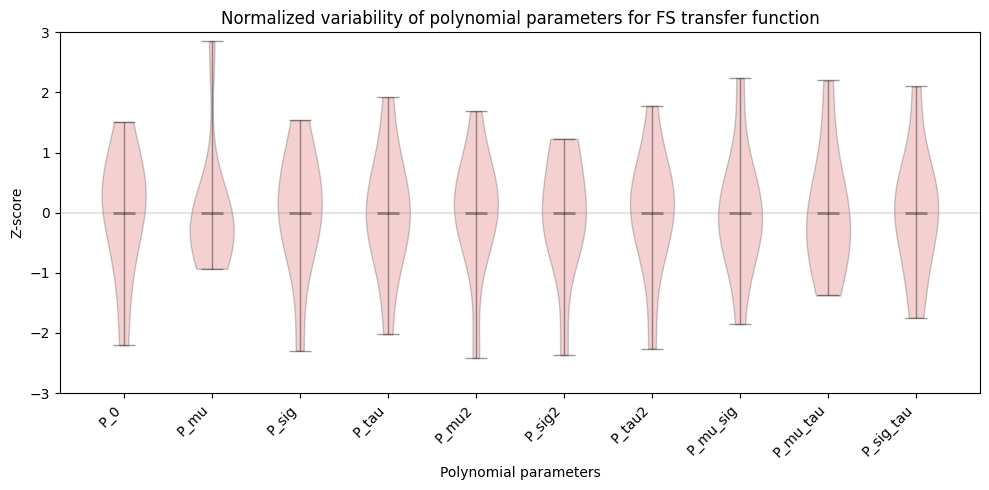

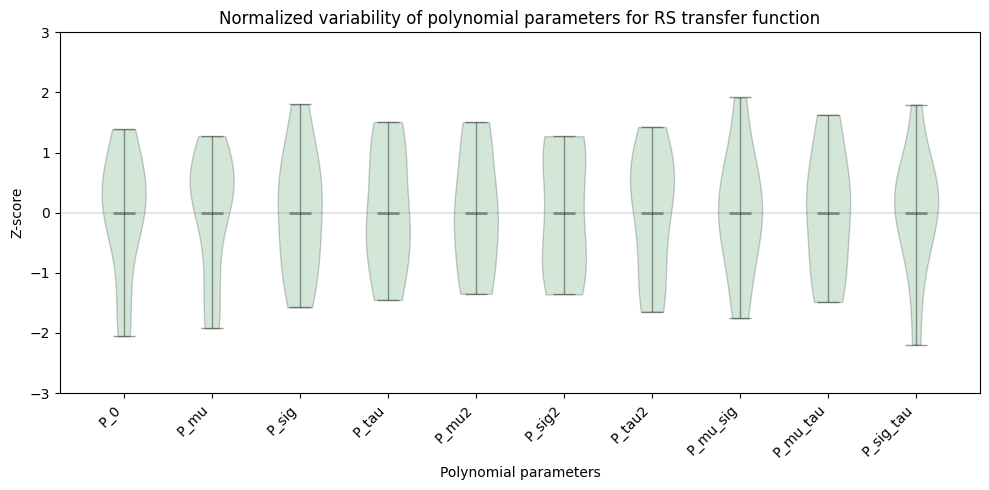

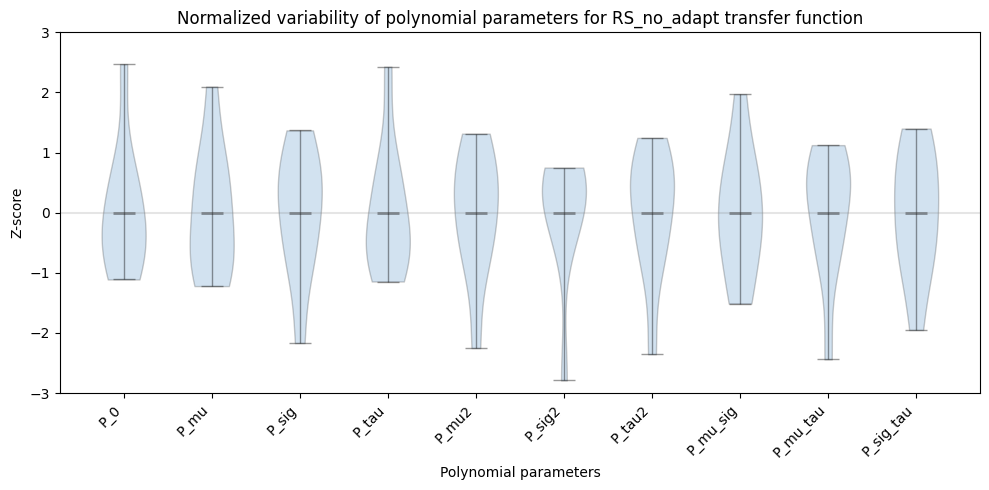

In [5]:
fig_violin = plot_violin('FS', poly_z_FS, params_name)
figs.append(fig_violin)
fig_violin = plot_violin('RS', poly_z_RS, params_name)
figs.append(fig_violin)
fig_violin = plot_violin('RS_no_adapt', poly_z_RS_no_adapt, params_name)
figs.append(fig_violin)

In [6]:
pca_FS = PCA()
X_pca_FS = pca_FS.fit_transform(poly_params_FS)
expl_var_FS = pca_FS.explained_variance_ratio_
cum_var_FS  = np.cumsum(expl_var_FS)

pca_RS_no_adapt = PCA()
X_pca_RS_no_adapt = pca_RS_no_adapt.fit_transform(poly_params_RS_no_adapt)
expl_var_RS_no_adapt = pca_RS_no_adapt.explained_variance_ratio_
cum_var_RS_no_adapt  = np.cumsum(expl_var_RS_no_adapt)

pca_RS = PCA()
X_pca_RS = pca_RS.fit_transform(poly_params_RS)
expl_var_RS = pca_RS.explained_variance_ratio_
cum_var_RS  = np.cumsum(expl_var_RS)

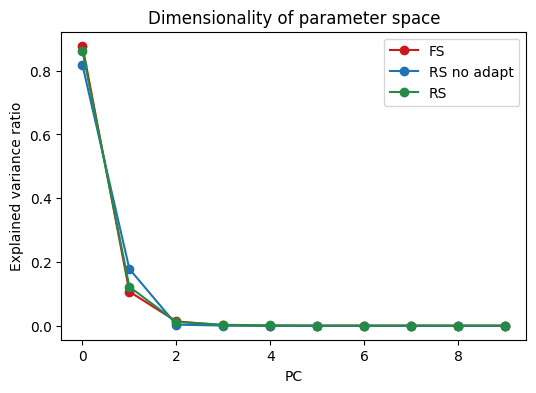

In [7]:
fig = plt.figure(figsize=(6,4))
plt.plot(expl_var_FS, 'o-', color=color_palette["FS"], label='FS')
plt.plot(expl_var_RS_no_adapt, 'o-', color=color_palette["RS_no_adapt"], label='RS no adapt')
plt.plot(expl_var_RS, 'o-', color=color_palette["RS"], label='RS')

plt.xlabel("PC")
plt.ylabel("Explained variance ratio")
plt.title("Dimensionality of parameter space")
plt.legend()

figs.append(fig)


In [8]:
loadings_values_FS = pd.DataFrame(
    pca_FS.components_[:2],   # only PC1 and PC2
    columns=params_name,
    index=['PC1', 'PC2']
)

print(loadings_values_FS)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.004810  0.028225 -0.291576  0.176779 -0.006201  0.004662 -0.692181   
PC2  0.000689 -0.007843  0.165403 -0.042638  0.000568 -0.954968  0.098379   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.034238 -0.063654  -0.631279  
PC2 -0.066499  0.025895  -0.209828  


In [9]:
loadings_values_RS_no_adapt = pd.DataFrame(
    pca_RS_no_adapt.components_[:2],   # only PC1 and PC2
    columns=params_name,
    index=['PC1', 'PC2']
)

print(loadings_values_RS_no_adapt)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.016350  0.018567 -0.335753  0.246063 -0.005173  0.235743 -0.792820   
PC2  0.008521  0.000032  0.004127  0.094287 -0.003426 -0.952818 -0.278445   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.054597 -0.105340  -0.357587  
PC2 -0.016639 -0.041299   0.060268  


In [10]:
loadings_values_RS = pd.DataFrame(
    pca_RS.components_[:2],   # only PC1 and PC2
    columns=params_name,
    index=['PC1', 'PC2']
)

print(loadings_values_RS)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.039219  0.022521 -0.244170  0.367805 -0.007591 -0.097815 -0.874346   
PC2 -0.031201  0.010752  0.414288 -0.066772 -0.002387 -0.281011 -0.147953   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.034722 -0.163661   0.030942  
PC2 -0.138672 -0.003562  -0.838279  


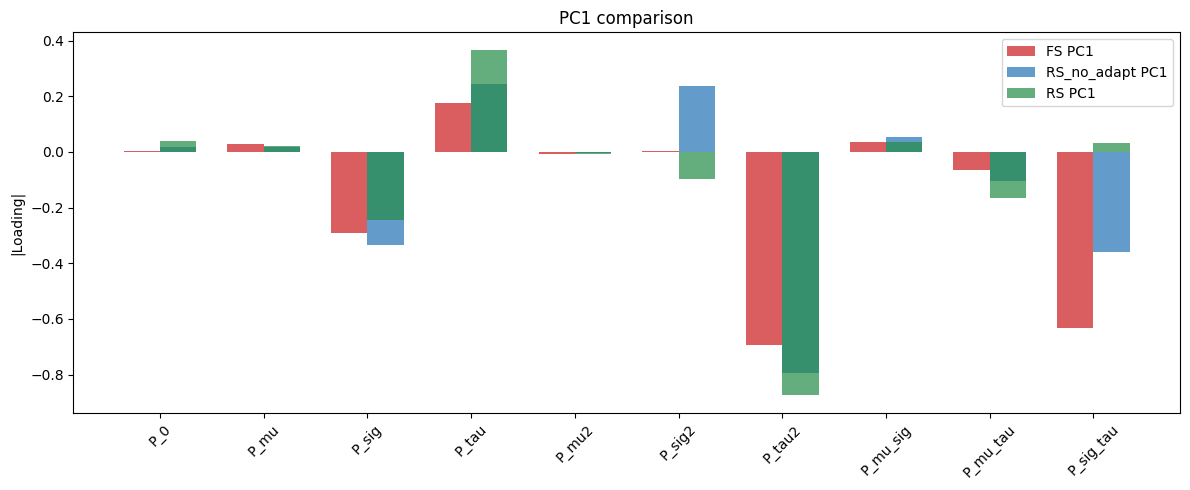

In [11]:
width = 0.35
x = np.arange(len(params_name))

fig = plt.figure(figsize=(12,5))

plt.bar(x - width/2, loadings_values_FS.loc['PC1'],
        width, label='FS PC1', color=color_palette["FS"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS_no_adapt.loc['PC1'],
        width, label='RS_no_adapt PC1', color=color_palette["RS_no_adapt"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS.loc['PC1'],
        width, label='RS PC1', color=color_palette["RS"], alpha=0.7)
plt.xticks(x, params_name, rotation=45)
plt.ylabel("|Loading|")
plt.title("PC1 comparison")
plt.legend()
plt.tight_layout()

figs.append(fig)


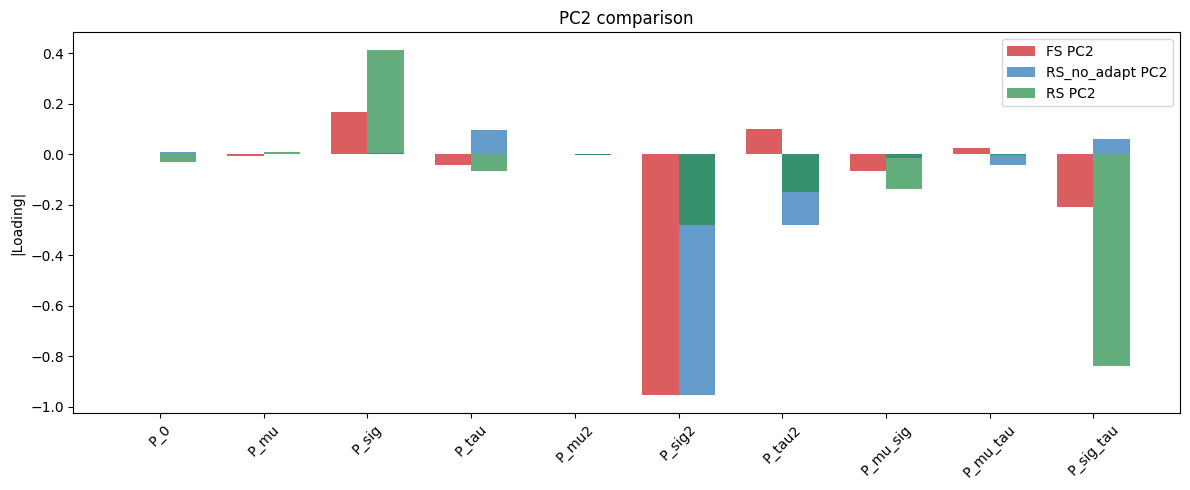

In [12]:
fig = plt.figure(figsize=(12,5))

plt.bar(x - width/2, loadings_values_FS.loc['PC2'],
        width, label='FS PC2', color=color_palette["FS"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS_no_adapt.loc['PC2'],
        width, label='RS_no_adapt PC2', color=color_palette["RS_no_adapt"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS.loc['PC2'],
        width, label='RS PC2', color=color_palette["RS"], alpha=0.7)


plt.xticks(x, params_name, rotation=45)
plt.ylabel("|Loading|")
plt.title("PC2 comparison")
plt.legend()
plt.tight_layout()

figs.append(fig)


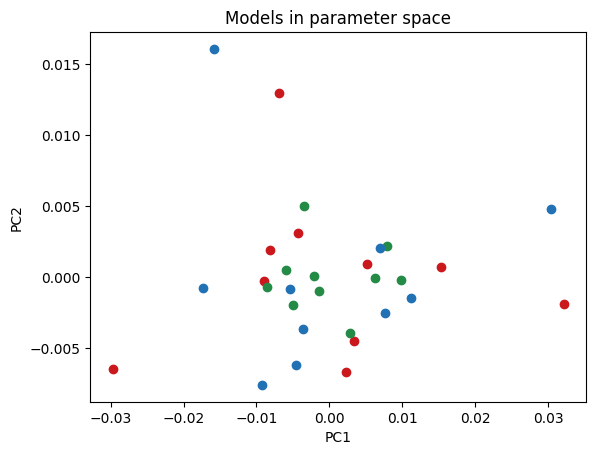

In [13]:
fig = plt.figure()
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], c=color_palette['FS'])
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], c=color_palette['RS'])
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], c=color_palette['RS_no_adapt'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Models in parameter space")
figs.append(fig)

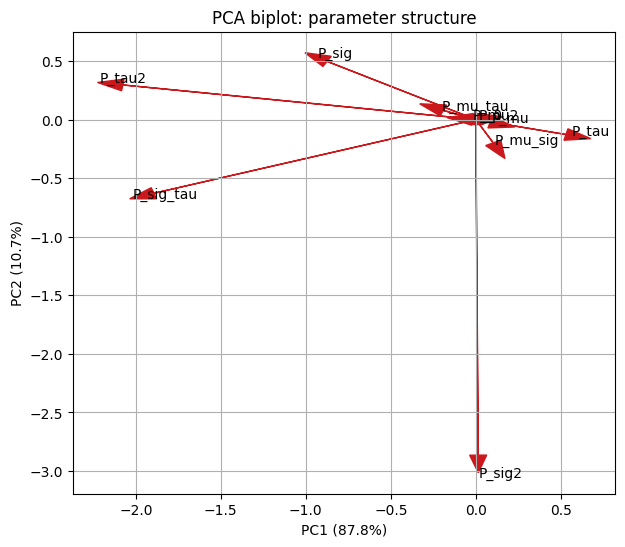

In [14]:
fig = plt.figure(figsize=(7,6))
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], color = color_palette['FS'], alpha=0.7)
loadings_FS = pca_FS.components_
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_FS[0,i]*3,
              loadings_FS[1,i]*3,
              head_width=0.1,
              color = color_palette['FS'])
    plt.text(loadings_FS[0,i]*3.2,
             loadings_FS[1,i]*3.2,
             f"{params_name[i]}")

plt.xlabel(f"PC1 ({expl_var_FS[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl_var_FS[1]*100:.1f}%)")
plt.title("PCA biplot: parameter structure")
plt.grid()
figs.append(fig)


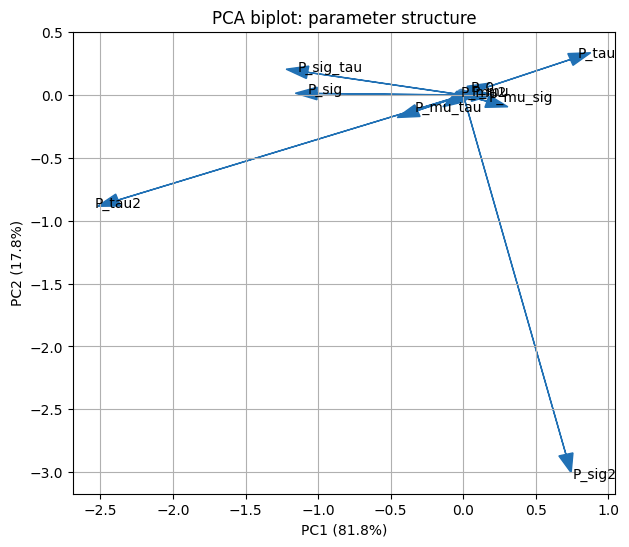

In [15]:
fig = plt.figure(figsize=(7,6))
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], color = color_palette['RS_no_adapt'], alpha=0.7)
loadings_RS_no_adapt = pca_RS_no_adapt.components_
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i]*3,
              loadings_RS_no_adapt[1,i]*3,
              head_width=0.1,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i]*3.2,
             loadings_RS_no_adapt[1,i]*3.2,
             f"{params_name[i]}")

plt.xlabel(f"PC1 ({expl_var_RS_no_adapt[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl_var_RS_no_adapt[1]*100:.1f}%)")
plt.title("PCA biplot: parameter structure")
plt.grid()
figs.append(fig)


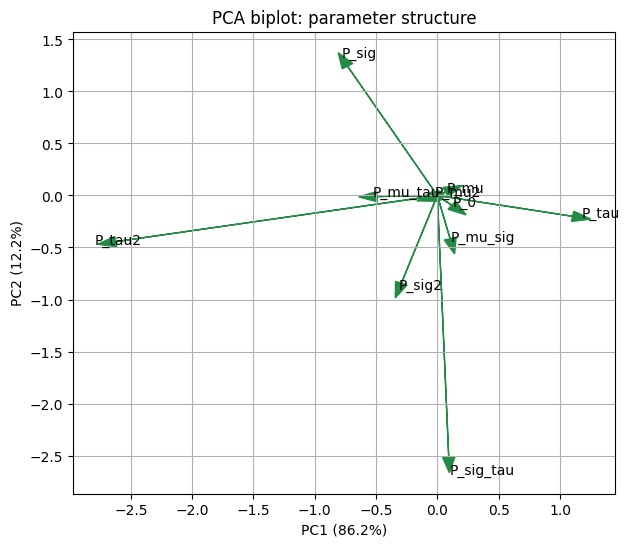

In [16]:
fig = plt.figure(figsize=(7,6))
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], color = color_palette['RS'], alpha=0.7)
loadings_RS = pca_RS.components_
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_RS[0,i]*3,
              loadings_RS[1,i]*3,
              head_width=0.1,
              color = color_palette['RS'])
    plt.text(loadings_RS[0,i]*3.2,
             loadings_RS[1,i]*3.2,
             f"{params_name[i]}")

plt.xlabel(f"PC1 ({expl_var_RS[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl_var_RS[1]*100:.1f}%)")
plt.title("PCA biplot: parameter structure")
plt.grid()
figs.append(fig)


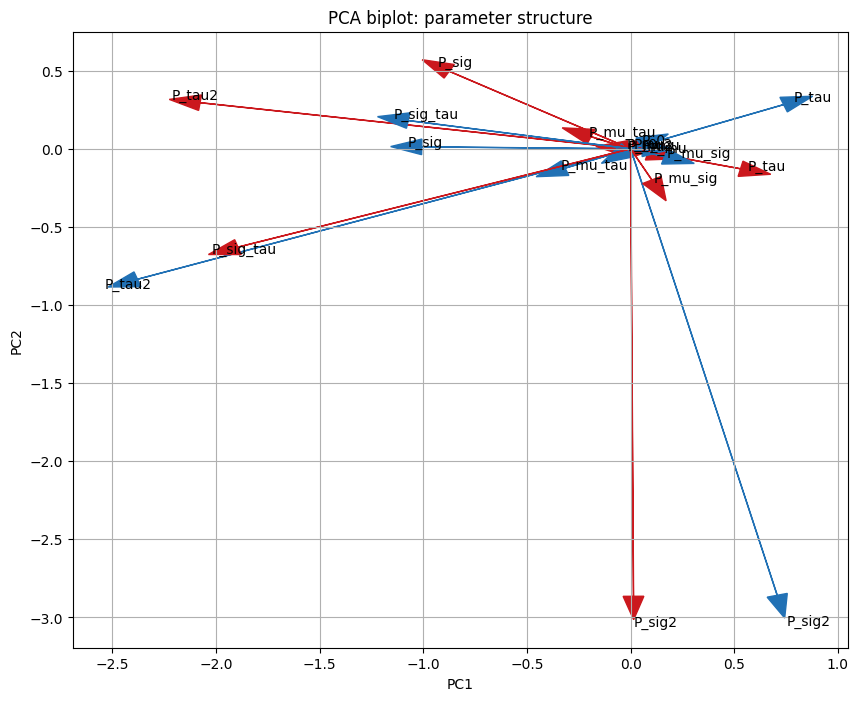

In [17]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], color = color_palette['FS'], alpha=0.7)
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_FS[0,i]*3,
              loadings_FS[1,i]*3,
              head_width=0.1,
              color = color_palette['FS'])
    plt.text(loadings_FS[0,i]*3.2,
             loadings_FS[1,i]*3.2,
             f"{params_name[i]}")
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i]*3,
              loadings_RS_no_adapt[1,i]*3,
              head_width=0.1,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i]*3.2,
             loadings_RS_no_adapt[1,i]*3.2,
             f"{params_name[i]}")    

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("PCA biplot: parameter structure")
plt.grid()

figs.append(fig)

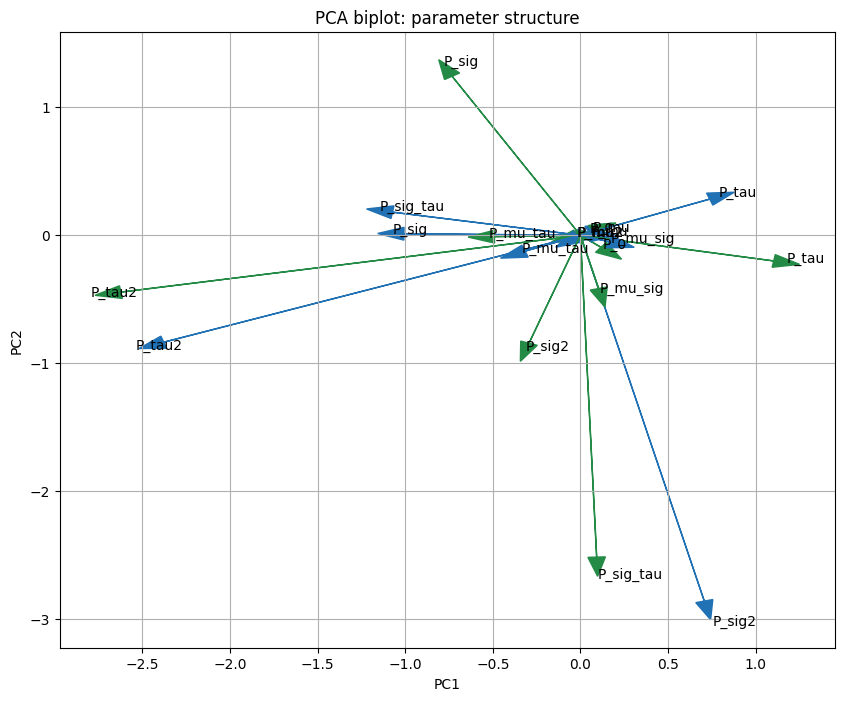

In [18]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], color = color_palette['RS_no_adapt'], alpha=0.7)
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], color = color_palette['RS'], alpha=0.7)
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_RS[0,i]*3,
              loadings_RS[1,i]*3,
              head_width=0.1,
              color = color_palette['RS'])
    plt.text(loadings_RS[0,i]*3.2,
             loadings_RS[1,i]*3.2,
             f"{params_name[i]}")
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i]*3,
              loadings_RS_no_adapt[1,i]*3,
              head_width=0.1,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i]*3.2,
             loadings_RS_no_adapt[1,i]*3.2,
             f"{params_name[i]}")    

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("PCA biplot: parameter structure")
plt.grid()

figs.append(fig)


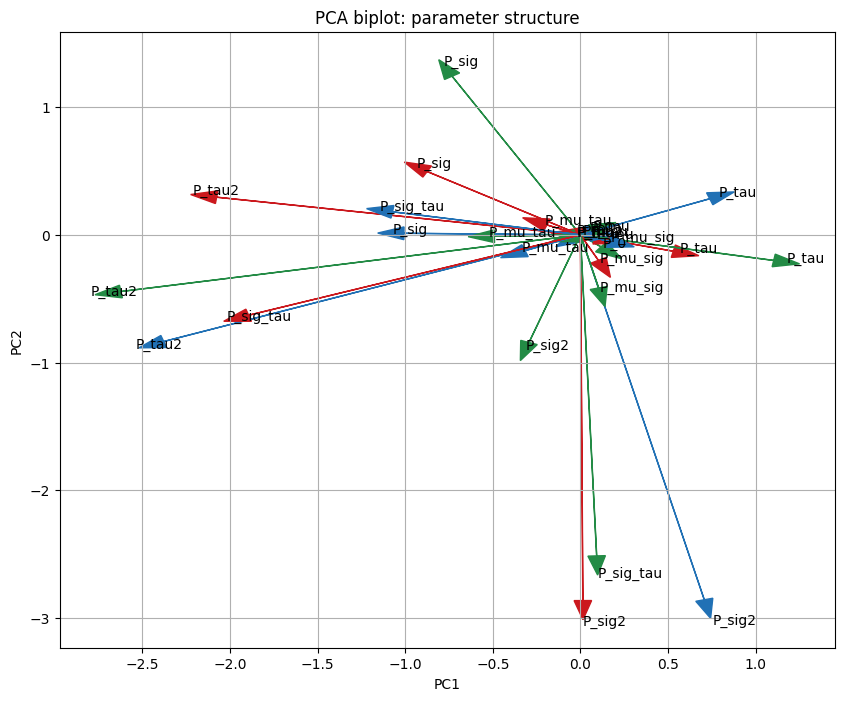

In [19]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], color = color_palette['FS'], alpha=0.7)
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], color = color_palette['RS'], alpha=0.7)
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], color = color_palette['RS_no_adapt'], alpha=0.7)

for i in range(n_params):
    plt.arrow(0, 0,
              loadings_FS[0,i]*3,
              loadings_FS[1,i]*3,
              head_width=0.1,
              color = color_palette['FS'])
    plt.text(loadings_FS[0,i]*3.2,
             loadings_FS[1,i]*3.2,
             f"{params_name[i]}")
    
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i]*3,
              loadings_RS_no_adapt[1,i]*3,
              head_width=0.1,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i]*3.2,
             loadings_RS_no_adapt[1,i]*3.2,
             f"{params_name[i]}")  
    
    plt.arrow(0, 0,
              loadings_RS[0,i]*3,
              loadings_RS[1,i]*3,
              head_width=0.1,
              color = color_palette['RS'])
    plt.text(loadings_RS[0,i]*3.2,
             loadings_RS[1,i]*3.2,
             f"{params_name[i]}")      

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("PCA biplot: parameter structure")
plt.grid()

figs.append(fig)


In [20]:
save_figs(fig_path, fig_name, figs)